# 1) Finite Element Forward Problem

____
|**<u>Indicative duration</u>** : 1 hour 30 minutes
|---|

There are 4 types of code cells:
- **<font color='green'>[RUN & OBSERVE]</font>** $\rightarrow$ the cell should be run directly without modification
- **<font color='orange'>[RUN & PLAY]</font>** $\rightarrow$ the cell can be run directly, but some parameters should be changed interactively
- **<font color='red'>[FILL & RUN]</font>**    $\rightarrow$ the cell should be filled before being run
- **<font color='magenta'>[FILL & PLAY]</font>** $\rightarrow$ the cell should be filled, and then some parameters should be changed interactively.

____
## A) First introductory example

|**<u>Indicative duration</u>** : 30 minutes|
|---|

### i) Reference function

We consider the following analytical function supported on the unit square $\Omega$:
$$ u_0 : \left \{ \begin{array}{rcl}
\Omega = [0,1]^2 & \rightarrow & \mathbb R \\
(x , y) &\mapsto & (x-0.5)^2 + (y-0.5)^2
\end{array} \right.$$

We can define and vizualize such an analytical function in `NGSolve`.

|**<font color='green'>[RUN & OBSERVE]</font>**|
|---|

In [ ]:
###############################################################################
## CODE CELL 1 : Define the geometry and reference function
###############################################################################

from ngsolve import unit_square, Mesh
mesh = Mesh(unit_square.GenerateMesh(maxh = 0.1)) # create the discretized geometry

from ngsolve import x, y
u0 = (x-0.5)**2 + (y-0.5)**2                      # define the analytic function

from ngsolve.webgui import Draw
Draw(u0, mesh,                                    # Draw the graph of the analytical function
     settings = { "Objects" : { "Wireframe" : False }, "deformation" :  1})

_____
### ii) Discretization

In general, we don't have access to the analytical expression of the function. We therefore use approximations that are computable with a finite number of parameters called **degrees of freedom** (dofs). 

The first step is to discretize the geometry into a finite set of cells, lines and vertices called a **mesh**.

- In 2D, we focus on **triangular meshes**, but there exist a wide variety of meshes (structured, unstructured, quadrangular, etc.)

|**<font color='green'>[RUN & OBSERVE]</font>**|
|---|

In [ ]:
###############################################################################
## CODE CELL 2 : Display the mesh
###############################################################################

Draw(mesh)    # draw the mesh defined in CODE CELL 1

____
### iii) Function spaces

The second step to define discretized function approximation is to chose an appropriate function space.
We focus on two types of function space:

- $ L^2(\Omega) = \left \{ v : \Omega \rightarrow \mathbb R, \int_\Omega |v|^2 \leq \infty \right \}$, discretized by **<u>discontinuous</u>** functions defined piecewise on **each cell** (element) of the mesh.

-  $ H^1(\Omega) = \left \{ v \in L^2(\Omega), \nabla v \in L^2(\Omega) \right \}$, discretized by **<u>continuous</u>** functions defined on **each node** (vertex) of the mesh.

A discretized function is then reduced to a **polynomial** into each cell of the mesh. The **degree** of this polynomial can be specified and is set up by the parameter `order`.

Other types of spaces can be defined, especially for vector fields having only *tangential* or *normal* continuity accross interfaces; see [this page](https://docu.ngsolve.org/v6.2.2103/i-tutorials/unit-2.3-hcurlhdiv/hcurlhdiv.html) for more information.

|**<font color='orange'>[RUN & PLAY]</font>**|
|---|

In [ ]:
###############################################################################
## CODE CELL 3 : Define and display GridFunctions 
###############################################################################

from ngsolve import H1, L2, GridFunction

polynomial_degree = 1
fes = H1(mesh, order=polynomial_degree)     # define the discretized function space on the mesh
#fes = L2(mesh, order=polynomial_degree)

gfu = GridFunction(fes)                     # a GridFunction is a discretized function on a given function space
gfu.vec.data[-1] = 1
Draw(gfu, mesh,                             # Draw the graph of the grid function
     settings = { "deformation" :  0.5})

_____
### iv) Least square formulation

A way to approximate any function on a discretized finite element space is to find $u\in H$ (with $H=L^2(\Omega)$ or $H^1(\Omega)$) **minimizing the integral of the square error** with the reference $u_0$: 

$$ u = \arg \min_{v\in H} J(v) = \frac{1}{2}\int_{x\in\Omega} ( v(x) -u_0 )^2 \; \mathrm{d} x$$


In what follows, we drop the $x$ dependency for conciseness :
- $u(x)\rightarrow u$
- no "$ x\in $"  and "$\mathrm{d}x$" in the integrals that are always evaluated on the geometric space $\Omega$.
  
|**<font color='red'>[FILL & RUN]</font>**|
|---|

In [ ]:
###############################################################################
## CODE CELL 4 : Define least square error using Integrate
###############################################################################

from ngsolve import Integrate

def J(u):
    """ integral of the half squared error """
    return Integrate((u - u0)**2  / 2, u.space.mesh)

#### Directional derivative
Given any function $v\in H$ , the **directionnal derivative** evaluates the first order variation of $J$ for a small step in the direction of $v$:
$$J'(u; v) =  \lim_{t\rightarrow 0} \frac{J(u+tv) - J(u)}{t} $$

**Exercise** : show that the directional derivative of the least square error reads

$$J'(u;v) = \int_\Omega (u - u_0) v $$

#### Gradient descent

For any scalar $\alpha >0$ we have always 

$$ J'(u; -\alpha (u-u_0) ) = -\alpha \int_\Omega (u-u_0)^2 \leq 0 $$

So $d=-(u-u_0)$ is a **<u>descent direction</u>**, because $J(u+\alpha d)< J(u)$ for $\alpha$ small enough.

|**<font color='red'>[FILL & RUN]</font>**|
|---|

In [ ]:
###############################################################################
## CODE CELL 5 : Define a descent direction
###############################################################################

def descent_direction(u):
    return -( u - u0 )

Having a descent direction means we can decrease $J$ by adding $\alpha (u_0-u)$ iteratively to the current trial function $u$ (or to its dofs, after discretization).

|**<font color='red'>[FILL & RUN]</font>**|
|---|

In [ ]:
###############################################################################
## CODE CELL 6 : Define descent algorithm and plot helper function
###############################################################################

from ngsolve import GridFunction
def myGradientDescent(u0,     # initial guess
                      J : callable = J,   # objective function 
                      d : callable = descent_direction,  # descent direction
                      alpha : float = 0.1, # initial step size
                      niter : int = 100,   # number of iterations
                      ) -> tuple[GridFunction, list[float]]:
    """ Simple gradient descent algorithm with basic step size adaptation """

    uOld = u0
    uNew, Jlist = GridFunction(u0.space), [J(u0)]
    for _ in range(niter): # optimization loop
        uNew.Set( uOld + alpha * d(uOld) )   # assign to UNew the value of uOld + alpha * descent_direction
        Jlist.append(J(uNew))                # store J(UNew) to inspect convergence
        
        # step size adaptation
        if Jlist[-1] < Jlist[-2]: # if J decreases, the step is accepted
            uOld.Set(uNew)        # set UOld value to UNew    
            alpha *= 1.2          # increase the step size
        else:                     # else, if J increases, the step is rejected
            Jlist.pop()           # forget the last J value
            alpha /=2             # decrease the step size

    return uOld, Jlist

import matplotlib.pyplot as plt
def plot(listToPlot, xlabel = "Iterations", ylabel = "J", title = "Convergence"):
    """ Shorthand to plot the convergence """
    plt.semilogy(listToPlot);  plt.xlabel(xlabel) ;plt.ylabel(ylabel)
    plt.title(title); plt.grid(); plt.show()

We can now play around and see what happens with interpolations from different function spaces.

**<u>Exercise</u>**  : Explore & analyze the influence of the function space on the result and the final error. 


|**<font color='orange'>[RUN & PLAY]</font>**|
|---|

In [ ]:
###############################################################################
## CODE CELL 7 : Play around with the optimization loop and plot convergence
###############################################################################

# Discretization
maxh = 0.2                       # max element size (should be bigger than 0.05)
mesh = Mesh(unit_square.GenerateMesh(maxh = maxh))   # generate the mesh
#-------------------------------------------------------------------
# Interpolation
order = 0                        # max polynomial order
fes = L2(mesh, order = order)    # generate L2 finite element space
#fes = H1(mesh, order = order)    # generate H1 finite element space
#-------------------------------------------------------------------
# Solve
uInit = GridFunction(fes)
uSol1, JList = myGradientDescent(uInit, alpha = 0.1, niter = 100) # what should be the optimal step size ?
#-------------------------------------------------------------------
# Plot error and convergence
print(f"Final mean squared error = {JList[-1]:.3e}")
Draw(uSol1, settings = {"deformation" :  0.5})
plot(JList, title = f"Convergence for {fes.type[0:2].swapcase()} space " + 
     f"({fes.mesh.ne} elements, order = {fes.globalorder})")

____
## B) Variational formulation

|**<u>Indicative duration</u>** : 30 minutes|
|---|

### i) Stationarity of the directional derivative

Since the least-square error is a **convex minimization problem**, we can solve it by cancelling the directional derivative for any direction $v\in H(\Omega)$.

$$ \forall v\in H(\Omega), \quad  J'(u;v) = 0$$
$$ \Rightarrow \forall v\in H(\Omega),  \quad \int_\Omega (u-u_0) v = 0 $$
$$ \Rightarrow \forall v\in H(\Omega),  \quad \underbrace{\int_\Omega u v}_{A(u,v)} = \underbrace{\int_\Omega u_0 v}_{l(v)} $$

- The arbitrary direction $v$ is called a **test function**
- The left-hand side $A(u,v)$ is a bilinear form
- The right hand side $l(v)$ is a linear form

_____
### ii) Weak form

- The last line is called a **variational formulation**; it represents the **weak form** of the following "**strong**" equation, obtained by removing the integrals and test functions :
$$ u = u_0  $$
- The variational form is called **weak** because $u$ might not be exactly equal to $u_0$, it is only the *best possible approximation* in the admissible space $H(\Omega)$.
- $u_0$ is **always** solution of the weak form, but  **the converse is not true**.

`NGSolve` is a toolbox to solve variational formulations numerically. We can define linear and bilinear form, with the syntaxes :
- `A = BilinearForm( <symbolic expression> * dx)`
- or `A = BilinearForm(fes)`, and then `A += <symbolic expression> * dx` for long expressions.
- `A += <symbolic expression> * dx("regionLabel")` is equivalent to restric the integral over a specific region.

For more syntax examples have a look at this [cheat sheet](B_NGSolve_cheat_sheet.ipynb).

|**<font color='red'>[FILL & RUN]</font>**|
|---|

In [ ]:
###############################################################################
## CODE CELL 8 : Define the variational formulation of the LSE problem
###############################################################################

#-------------------------------------------
# Finite element space
order = 0
fes = L2(mesh, order = order)
#fes = H1(mesh, order = order)
#-------------------------------------------
# Definition of linear and bilinear forms
from ngsolve import BilinearForm, LinearForm, dx
u = fes.TrialFunction()
v = fes.TestFunction()
A = BilinearForm( u*v * dx )  # define the bilinear form
l = LinearForm( u0*v * dx )   # define the linear form

______
### iii) Discretization and assembly

After **discretization**:

- Fields are equivalent to vectors $u_i$
- Bilinear form is equivalent to a matrix : $K_{ij} = A(u_j, v_i) $
- Linear form is equivalent to a vector $f_i = l(v_i)$

with $u_i, v_j$ the unitary function associated to **degress of freedom** $i,j$, repsectively. The discretization process is called "**assembly**". Then, one has to solve the linear system :

$$ K_{ij} u_{j} = f_{i} $$

The assembly process involves calculating elementary integrals and accumulating them in the correct positions within the matrix/vector. Efficient general assembly is not a trivial task; fortunately, `NGsolve` handles it seamlessly.

|**<font color='green'>[RUN & OBSERVE]</font>**|
|---|

In [ ]:
###############################################################################
## CODE CELL 9 : Assembly
###############################################################################

# Assembly step (difficult to implement... but NGsolve takes care of it!)
K = A.Assemble().mat  # K is now a sparse matrix
f = l.Assemble().vec  # f is now a vector

We can access the matrix and vizualize it.
- Note the **symmetry** of the matrix. Indeed, it comes from a symmetric bilinear form!
- Note the difference in **sparsity patterns** between $H^1$ and $L^2$ function spaces.

|**<font color='green'>[RUN & OBSERVE]</font>**|
|---|

In [ ]:
###############################################################################
## CODE CELL 10 : Matrix inspection
###############################################################################

import scipy.sparse as sp
import matplotlib.pylab as plt
rows, cols, vals = K.COO()      # Extract the matrix in scipy.sparse COO format
print(f"Non-zero terms ratio: {len(vals)/(K.height*K.width)*100:.2f} %")
plt.spy(sp.csr_matrix((vals,(rows,cols))) , markersize = 6)
plt.show()    # show non-zero terms of the matrix

______
### iv) Solving the problem

Solving the mean-square problem is now equivalent to solving the previous matrix system, without the need to iterate as in gradient-descent approach.

We can check that the obtained solution is the same as the one found with gradient descent.

|**<font color='green'>[RUN & OBSERVE]</font>**|
|---|

In [ ]:
###############################################################################
## CODE CELL 11 : Solve the linear system and plot the solution
###############################################################################

uSol2 = GridFunction(fes)
uSol2.vec.data = K.Inverse() * f
print(f"Difference with gradient-descent solution = {Integrate((uSol1-uSol2)**2, mesh)**0.5 :.3e}")
Draw(uSol2,  settings = {"deformation" :  0.5})

**NB** : Actually, the inverse of the matrix is not explicitely computed. The matrix is *decomposed* and put in a specific form (e.g., upper triangular) such that the linear system is now easy to solve. This is the principle of a direct solver.

____
## C) Solving a Partial Differential Equation (PDE)

|**<u>Indicative duration</u>** : 30 minutes|
|---|

Now we want to solve a PDE using finite element method, for instance the b-conform magnetostatic equation.

### i) Geometry

We consider the following 2D domain $\Omega$ with a boundary $\partial \Omega$, containing a primary winding $P$ with back-and-forth conductors $P_+$ and $P_-$, as well as a secondary winding with back-and-forth conductors $S_+$ and $S_-$; we call $\Omega_c = \Omega / (P_+ \cup P_- \cup S_+ \cup S_-)$.
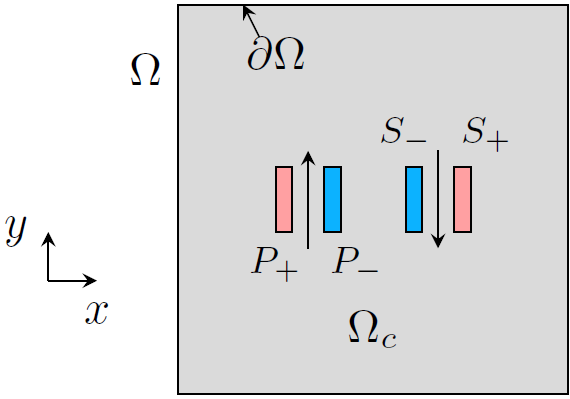

|**<font color='green'>[RUN & OBSERVE]</font>**|
|---|

In [ ]:
###############################################################################
## CODE CELL 12 : Import transformer mesh
###############################################################################

from utils.geometry import transformer
from ngsolve.webgui import Draw

mesh = transformer(maxh = 0.1)                   #  mesh the transformer geometry
print(f"Region names : {mesh.GetMaterials()}")   # display the regions (materials) labels
print(f"Line names : {mesh.GetBoundaries()}")    # display the lines (boundaries) labels
Draw(mesh)

____
### ii) Equation

We consider a no-load transformer. Only the primary winding is fed with current.

#### Strong local equation
From Maxwell equations and magnetic constitutive law we can write

$$ \text{curl}\;(\nu\;\text{curl}\; a) = j $$

with 
- $a$ the magnetic vector potential such that $b = \text{curl}\; a$
- $\nu$ the magnetic reluctivity (inverse of the magnetic permeability); here $\nu = 1/\mu_0$ everywhere.
- $j$ the current density (1A/mm²), that is positive in $P_+$, negative in $P_-$ and 0 elsewhere.

|**<font color='green'>[RUN & OBSERVE]</font>**|
|---|

In [ ]:
###############################################################################
## CODE CELL 13 : Define physical constants
###############################################################################

from numpy import pi
mu0 = 4e-7 * pi    # magnetic permeability of air (H/m)
nu = 1/mu0         # magnetic reluctivity (m/H)
j = 1e6            # current density (A/mm²)

#### Boundary condition

We take a homogeneous Dirichlet boundary condition, i.e $a\times n=0$ on $\partial \Omega$ so that $b$ is tangential to the boundary.

#### Weak formulation

By projecting on a basis of test functions and using integration by part, we obtain the weak form 

find $a\in H = \{ v \in H(\text{curl}, \Omega), v\times n = 0~\text{on}~ \partial\Omega\}$, such that

$$ \forall v \in H, \quad \int_\Omega \text{curl}\;v \cdot \nu \text{curl}\;a = \int_\Omega v j $$

In 2D, we can simplify further by taking only the $z$ components of $a$ and $j$, $\text{curl}(\cdot) = \begin{bmatrix} 0 & 1 \\ -1 & 0 \end{bmatrix} \text{grad}(\cdot)$ so $H = H^1_0(\Omega)$ to have


$$ \boxed{
\text{find $a_z\in H^1_0(\Omega)$, such that }
\forall v \in H^1_0(\Omega), \quad \int_\Omega \text{curl}\;v \cdot \nu \text{curl}\;a_z = \int_\Omega v j_z 
}$$

We shall now implement the variational formulation in NGSolve; have a look at this  [cheat sheet](B_NGSolve_cheat_sheet.ipynb) for syntax examples.

|**<font color='red'>[FILL & RUN]</font>**|
|---|

In [ ]:
###############################################################################
## CODE CELL 14 : Define the symbolic variational formulation
###############################################################################

# Function space
fes = H1(mesh, dirichlet = "out")

# Test and trial functions
az = fes.TrialFunction()
v = fes.TestFunction()

# Curl operator
from ngsolve import CF, grad

def curl(v):
    R = CF(((0,1),(-1,0)), dims = (2,2))  # Rotation matrix of angle -pi/2
    return R * grad(v)

# Bilinear form
bf = BilinearForm(fes)
bf += curl(v) * (nu * curl(az)) * dx

# Linear form
lf = LinearForm(fes)
lf += j * v * dx("Pp") - j * v * dx("Pm")

### iii) Discretize and solve the problem

Then we assemble and solve the linear system.

|**<font color='red'>[FILL & RUN]</font>**|
|---|

In [ ]:
###############################################################################
## CODE CELL 15 : Define the symbolic variational formulation
###############################################################################

K = bf.Assemble().mat
f = lf.Assemble().vec
sol = GridFunction(fes)
Kinv = K.Inverse(freedofs = fes.FreeDofs())
sol.vec.data = Kinv * f
Draw(sol)

Since the assembly and solving part is always the same piece of code, we can encapsulate this part into a predefined function `solve`.

|**<font color='green'>[RUN & OBSERVE]</font>**|
|---|

In [ ]:
###############################################################################
## CODE CELL 16 : Shorthand to solve the linear system
###############################################################################

from utils.solver import solve

sol, Kinv = solve(bf, lf)  # return the solution and the matrix inverse for further use
Draw(sol)

### iv) Post-processing

We can compute post-processed quantities such as:
- the flux density $b = \text{curl}\; a$

|**<font color='red'>[FILL & RUN]</font>**|
|---|

In [ ]:
###############################################################################
## CODE CELL 17 : 
###############################################################################

B = curl(sol)
Draw(B, mesh, 
     vectors = { "grid_size":30},
     settings = {"Objects": {"Surface" : False}})

- the magnetic flux within the secondary coil
$$\displaystyle \phi = L_z N_s \left(\langle a\rangle_{S^+} - \langle a\rangle_{S^-} \right) = L_z N_s \left(\frac{1}{|S^+|} \int_{S^+} a - \frac{1}{|S^-|}\int_{S^-} a \right)$$
with $N_s$ the number of turns of the secondary winding, and $L_z$ the length of the transformer in the $z$ direction (normalized to $L_z = 1m$ here).

|**<font color='red'>[FILL & RUN]</font>**|
|---|

In [ ]:
###############################################################################
## CODE CELL 18 : Compute the flux
###############################################################################

def flux(sol, Ns = 100, Lz = 1):
    """ Compute the flux in the secondary coil """
    Sp = Integrate(1, mesh, definedon = mesh.Materials("Sp"))
    Sm = Integrate(1, mesh, definedon = mesh.Materials("Sm"))
    aSp = Integrate(sol, mesh, definedon = mesh.Materials("Sp"))
    aSm = Integrate(sol, mesh, definedon = mesh.Materials("Sm"))
    return Ns * Lz * (aSp/Sp - aSm/Sm)

print(f"Secondary flux = {flux(sol):.3e} Wb/m")